# Electron reconstruction efficiency

This notebook computes the reconstruction efficiency versus generator-level electron $p_T$ for:

- **Low-$p_T$ (no cross-cleaning)** — useful for showing the intrinsic low-$p_T$ reconstruction performance.
- **GED**
- **Total reconstruction** = GED + **cross-cleaned** low-$p_T$

The total uses the cross-cleaned low-$p_T$ numerator so that an electron reconstructed by both
collections is not counted twice.


In [16]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")

import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Change the signal point or input file here; the rest of the notebook should not need editing.

In [17]:
# Input
#f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/Trial_dxy_pT_Resolution_dask.coffea"

signal_file = "/uscms_data/d3/reshmar/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/SampleFactoryProducts_2022/Sig77_14_ctau1_100.coffea"
sig_histo = util.load(signal_file)[0]

# Signal point
M1 = 70
DELTA = 0.2
CTAU = 1
YEAR = 2022
CUT = "cut1"

# Variables stored in the coffea output
VARIABLES = {
    "denominator": "gen_ele_pt",
    "lpt_xclean": "pT_genElePos_Lpt",
    "lpt_noxclean": "pT_genElePos_Lpt_Noxclean",
    "ged": "pT_genElePos_GED",
}


## Helper functions

In [18]:
def get_counts(variable):
    """Return histogram counts and bin edges for one signal variable.

    plot_signal_1D is used only as the existing histogram accessor here.
    The temporary figure is closed immediately because the final efficiency
    plot is made separately below.
    """
    fig, ax = plt.subplots()

    plot_cfg = {
        "variable": variable,
        "cut": CUT,
        "year": YEAR,
    }

    style_cfg = {
        "fig": fig,
        "ax": ax,
        "rebin": None,
        "xlim": None,
        "doLogy": False,
        "doLogx": False,
        "doDensity": False,
        "doYerr": False,
        "xlabel": None,
        "ylabel": None,
        "label": None,
        "flow": None,
        "doSave": False,
        "outDir": None,
        "outName": None,
    }

    counts, edges = ptools.plot_signal_1D(
        sig_histo, M1, DELTA, CTAU, plot_cfg, style_cfg
    )

    plt.close(fig)
    return np.asarray(counts, dtype=float), np.asarray(edges, dtype=float)


def efficiency(numerator, denominator):
    """Return binomial efficiency and uncertainty.

    Empty denominator bins become NaN instead of producing divide-by-zero
    warnings.
    """
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)

    eff = np.full_like(denominator, np.nan, dtype=float)
    valid = denominator > 0
    eff[valid] = numerator[valid] / denominator[valid]
    
    unc = hist.intervals.ratio_uncertainty(
        numerator,
        denominator,
        "efficiency"
    )
    return eff, unc


def assert_same_binning(reference_edges, **other_edges):
    """Stop immediately if numerator and denominator bins do not match."""
    for name, edges in other_edges.items():
        if not np.array_equal(reference_edges, edges):
            raise ValueError(
                f"{name} does not have the same binning as the denominator."
            )


## Read the four histograms

In [19]:
den, edges = get_counts(VARIABLES["denominator"])
lpt_xclean, edges_lpt_xclean = get_counts(VARIABLES["lpt_xclean"])
lpt_noxclean, edges_lpt_noxclean = get_counts(VARIABLES["lpt_noxclean"])
ged, edges_ged = get_counts(VARIABLES["ged"])

assert_same_binning(
    edges,
    lpt_xclean=edges_lpt_xclean,
    lpt_noxclean=edges_lpt_noxclean,
    ged=edges_ged,
)

bin_centers = 0.5 * (edges[:-1] + edges[1:])

print(f"Number of pT bins: {len(den)}")
print(f"Total generated electrons in histogram: {np.sum(den):.0f}")


                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  77.0   14.0   1.0  70.0  84.0    0.2   

                                                                      name  
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  
                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  77.0   14.0   1.0  70.0  84.0    0.2   

                                                                      name  
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  
                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  77.0   14.0   1.0  70.0  84.0    0.2   

                                                                      name  
sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  sig_2022_Mchi-77p0_dMchi-14p0_ctau-1  
                                      mchi  dmchi  ctau    m1    m2

## Compute efficiencies

The individual low-$p_T$ curve uses the **non-cross-cleaned** collection:

\[
\epsilon_{\mathrm{LPT}} =
\frac{N(\mathrm{gen\ matched\ to\ LPT,\ no\ xclean})}
     {N(\mathrm{gen})}.
\]

The total uses the **cross-cleaned** low-$p_T$ collection:

\[
\epsilon_{\mathrm{total}} =
\frac{N(\mathrm{GED}) + N(\mathrm{LPT,\ xclean})}
     {N(\mathrm{gen})}.
\]

This avoids counting the same generated electron twice when it is reconstructed
in both GED and low-$p_T$.


In [20]:
eff_lpt, unc_lpt = efficiency(lpt_noxclean, den)
eff_ged, unc_ged = efficiency(ged, den)

total_num = ged + lpt_xclean
eff_total, unc_total = efficiency(total_num, den)

# Sanity check: for a binomial efficiency, numerator should not exceed denominator.
if np.any(total_num > den):
    bad_bins = np.where(total_num > den)[0]
    print(
        "WARNING: total numerator exceeds denominator in bins:",
        bad_bins.tolist(),
    )


## Final efficiency plot

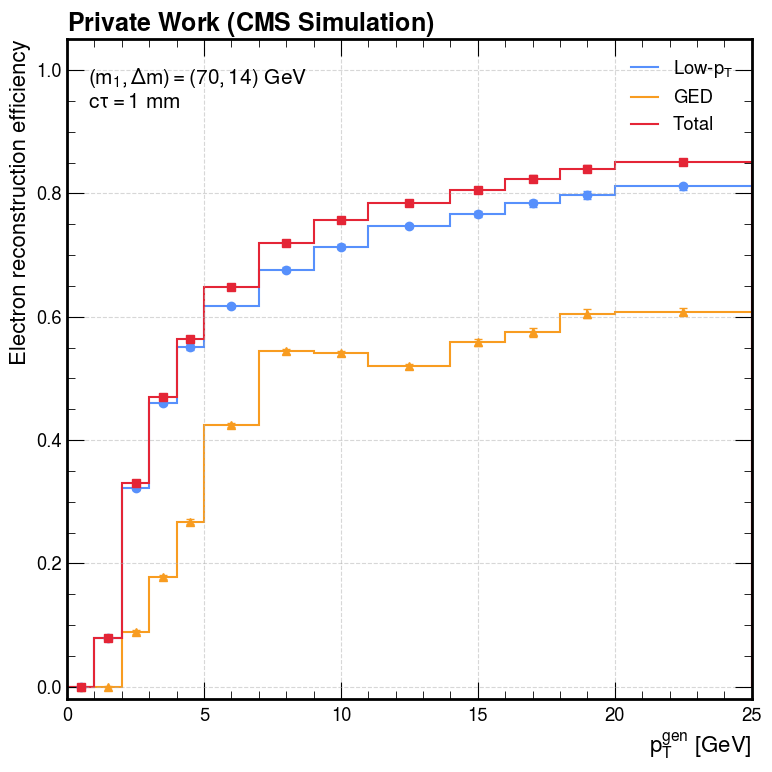

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

curves = [
    {"eff": eff_lpt, "unc": unc_lpt, "label": "Low-$p_T$", "marker": "o"},
    {"eff": eff_ged, "unc": unc_ged, "label": "GED", "marker": "^"},
    {"eff": eff_total, "unc": unc_total, "label": "Total", "marker": "s"},
]

for curve in curves:
    stairs = ax.stairs(
        curve["eff"],
        edges,
        linewidth=1.5,
        label=curve["label"],
    )

    ax.errorbar(
        bin_centers,
        curve["eff"],
        yerr=curve["unc"],
        fmt=curve["marker"],
        linestyle="none",
        capsize=3,
        color=stairs.get_edgecolor(),
    )

ax.set(
    xlim=(0, 25),
    ylim=(-0.02, 1.05),
    xlabel=r"$p_T^{\mathrm{gen}}$ [GeV]",
    ylabel="Electron reconstruction efficiency",
)

ax.set_title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$",
    fontsize=18,
    loc="left",
)

ax.text(
    0.03,
    0.96,
    rf"$(m_1,\Delta m)=({M1},{M1 * DELTA:g})\ \mathrm{{GeV}}$"
    "\n"
    rf"$c\tau={CTAU}\ \mathrm{{mm}}$",
    transform=ax.transAxes,
    fontsize=15,
    va="top",
    ha="left",
)

ax.grid(True, which="major", linestyle="--", alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()


## Optional numerical inspection

In [22]:
for name, eff in [
    ("Low-pT", eff_lpt),
    ("GED", eff_ged),
    ("Total", eff_total),
]:
    print(f"{name:8s}: {np.array2string(eff, precision=3)}")


Low-pT  : [0.    0.079 0.323 0.46  0.551 0.617 0.677 0.714 0.747 0.767 0.784 0.798
 0.811]
GED     : [0.000e+00 2.966e-04 8.866e-02 1.781e-01 2.679e-01 4.237e-01 5.439e-01
 5.410e-01 5.199e-01 5.586e-01 5.746e-01 6.053e-01 6.084e-01]
Total   : [0.    0.079 0.33  0.471 0.563 0.649 0.72  0.757 0.785 0.806 0.824 0.84
 0.851]
